# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who**:
The primary audience for this analysis would be retail decision makers, such as product managers, marketing teams, or data driven strategy leads responsible for improving customer engagement and sales performance.

**What**:
The core message of the data story is that customer purchasing behavior and product interactions follow highly skewed patterns, with revenue and engagement concentrated among a subset of customers and products. Understanding these patterns is essential for designing effective personalized recommendation systems.

**How**:
The data story would be communicated using clear distribution visualizations such as histograms and summary statistics that highlight revenue concentration, basket size variability, and long tail product behavior. Visuals would be simplified to focus attention on key patterns, reducing unnecessary clutter and emphasizing insights relevant to decision making.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import matplotlib.pyplot as plt
from pathlib import Path

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# Part 1: EDA on U.S. E Commerce Records

In [2]:
# Load Dataset
path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1


### Initial Data Structure and Context

In [3]:
# KaggleHub returns a folder path; this dataset contains exactly one CSV
dataset_dir = Path(path)
csv_files = sorted(dataset_dir.rglob("*.csv"))

data_file = csv_files[0]

df = pd.read_csv(data_file, encoding="cp1252")

print("Loaded file:", data_file.name)
print("df shape:", df.shape)
print("Unique Customer IDs:", df["Customer ID"].nunique())
print("Unique Order IDs:", df["Order ID"].nunique())
display(df.head())

Loaded file: US  E-commerce records 2020.csv
df shape: (3312, 19)
Unique Customer IDs: 693
Unique Order IDs: 1687


,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


The U.S. E Commerce dataset contains 3312 transaction level records and 19 variables. Each row represents a customer purchase event and includes both a unique Order ID and Customer ID, allowing analysis at both transaction and customer levels.

Of the 3312 rows, there are 693 unique customer IDs and 1697 unique order IDs. This means that most of the data is comprised of orders containing multiple products.

### Preprocessing

In [4]:
# Basic structure + summary stats 
df.info()
display(df.describe(include="all"))
print("Duplicated rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   str    
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   str    
 3   Ship Mode     3312 non-null   str    
 4   Customer ID   3312 non-null   str    
 5   Segment       3312 non-null   str    
 6   Country       3312 non-null   str    
 7   City          3312 non-null   str    
 8   State         3312 non-null   str    
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   str    
 11  Product ID    3312 non-null   str    
 12  Category      3312 non-null   str    
 13  Sub-Category  3312 non-null   str    
 14  Product Name  3312 non-null   str    
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null   float64
d

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,3312,3312.000000,3312,3312,3312,3312,3312,3312,3312,3312.000000,3312,3312,3312,3312,3312,3312.000000,3312.000000,3312.000000,3312.000000
unique,322,NaN,1687,4,693,3,1,350,47,NaN,4,1525,3,17,1511,NaN,NaN,NaN,NaN
top,02-09-20,NaN,CA-2017-100111,Standard Class,JL-15835,Consumer,United States,New York City,California,NaN,West,FUR-CH-10003774,Office Supplies,Binders,Easy-staple paper,NaN,NaN,NaN,NaN
freq,36,NaN,14,1897,20,1668,3312,306,663,NaN,1095,8,2002,500,16,NaN,NaN,NaN,NaN
mean,NaN,5087.107488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56186.515097,NaN,NaN,NaN,NaN,NaN,221.381418,3.766908,0.156467,28.212340
std,NaN,2817.482266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31980.375516,NaN,NaN,NaN,NaN,NaN,585.257531,2.221776,0.207429,241.864342
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1841.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-3839.990400
25%,NaN,2655.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27978.750000,NaN,NaN,NaN,NaN,NaN,17.018000,2.000000,0.000000,1.763200
50%,NaN,5183.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60472.500000,NaN,NaN,NaN,NaN,NaN,53.810000,3.000000,0.200000,8.296800
75%,NaN,7498.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90032.000000,NaN,NaN,NaN,NaN,NaN,205.105700,5.000000,0.200000,28.315125


Duplicated rows: 0


The dataset was reviewed for missing values, duplicate records, and invalid numerical entries. No null or empty values were found across any of the 19 variables, indicating that the dataset is complete and does not require imputation.

A check for duplicate rows confirmed that there are no repeated transactions, ensuring that revenue and purchase frequency metrics are not artificially inflated. Numerical fields such as revenue, quantity, and price were also examined for negative or zero values in inappropriate contexts, and none were identified.

Data types were verified, and date fields were formatted appropriately to allow for temporal analysis. Overall, the dataset is clean and structurally sound!

### Customer Level Feature Engineering

In [5]:
customer_summary = df.groupby("Customer ID").agg({
"Order ID": "nunique",
"Quantity": "sum",
"Sales": "sum",
"Profit": "sum"
}).reset_index()

print("Customer summary:")
display(customer_summary.head())

customer_summary.describe()

Customer summary:


,Customer ID,Order ID,Quantity,Sales,Profit
0,AA-10315,1,5,374.480,96.5050
1,AA-10375,2,13,206.732,68.9195
2,AA-10480,1,3,15.552,5.4432
3,AA-10645,1,2,12.960,6.2208
4,AB-10060,4,31,2936.264,477.8292


,Order ID,Quantity,Sales,Profit
count,693.000000,693.000000,693.000000,693.000000
mean,2.434343,18.002886,1058.030671,134.833001
std,1.307085,12.960701,1463.910713,559.192347
min,1.000000,1.000000,1.188000,-3825.339400
25%,1.000000,8.000000,204.405000,5.176100
50%,2.000000,16.000000,604.910000,58.778000
75%,3.000000,25.000000,1334.641600,199.168200
max,8.000000,92.000000,14203.278000,6780.896300


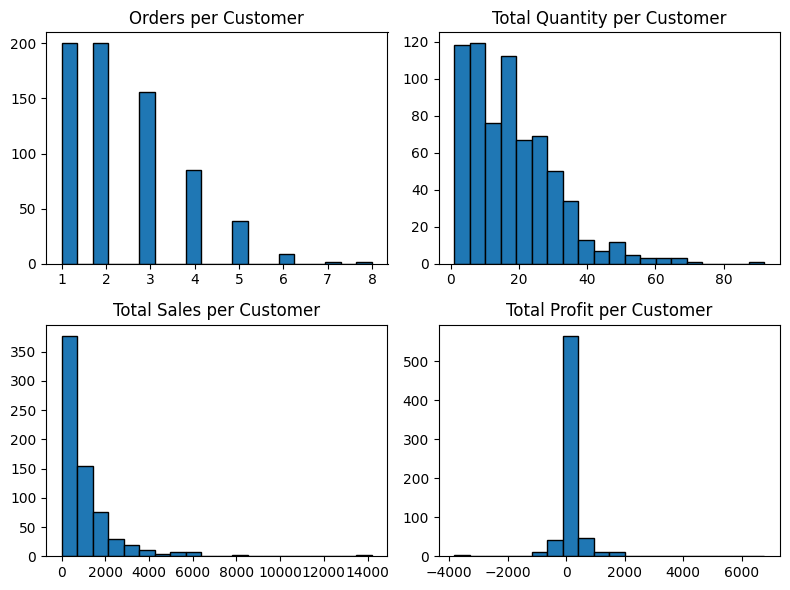

In [6]:
# Create a 2x2 grid of histograms
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0, 0].hist(customer_summary["Order ID"], bins=20, edgecolor='black')
axes[0, 0].set_title("Orders per Customer")

axes[0, 1].hist(customer_summary["Quantity"], bins=20, edgecolor='black')
axes[0, 1].set_title("Total Quantity per Customer")

axes[1, 0].hist(customer_summary["Sales"], bins=20, edgecolor='black')
axes[1, 0].set_title("Total Sales per Customer")

axes[1, 1].hist(customer_summary["Profit"], bins=20, edgecolor='black')
axes[1, 1].set_title("Total Profit per Customer")

plt.tight_layout()
plt.show()


The customer level metrics display strong right skew across orders, quantity, and sales. Most customers place one to two orders and generate relatively low total sales, while a small subset contributes substantially higher revenue. This indicates revenue concentration among high value customers, a common retail pattern that supports segmentation and targeted recommendation strategies.

Total profit also shows variability, with some customers generating negative profit, suggesting discounting, returns, or low margin transactions. The presence of both high value outliers and low or negative profit customers highlights the importance of modeling not only revenue but also profitability in recommendation system design.

### Part 1 Conclusion:

Overall, the dataset looks **clean and usable** for EDA and for building recommendation/segmentation features. Next steps would be (1) parse Order Date to datetime, (2) encode key categorical variables if modeling, and (3) check for **class imbalance** in categorical columns (Segment/Category/Region) and handle **skew/outliers** in numeric features since both can affect model performance.

# Part 2: EDA on Instacart Market Basket Analysis

In [7]:
# Download latest version
path2 = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path2)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1


### Initial Data Structure and Context

In [8]:
instacart_dir = Path(path2)
print("Instacart dataset folder:", instacart_dir)

# Sampling orders to get a manageable subset of order IDs for loading the large order_products_prior.csv
orders = pd.read_csv(instacart_dir / "orders.csv", usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"])

sample_orders = orders.sample(n=10000, random_state=42)
sample_order_ids = set(sample_orders["order_id"].astype(int))


# Load these files fully as-is
products = pd.read_csv(instacart_dir / "products.csv")

# This file is very large; load only a small sample in chunks to avoid kernel crashes
usecols = ["order_id", "product_id", "add_to_cart_order", "reordered"]

chunks = []
for chunk in pd.read_csv(
    instacart_dir / "order_products__prior.csv",
    usecols=usecols,
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
    chunksize=200_000
):
    filtered = chunk[chunk["order_id"].isin(sample_order_ids)]
    if not filtered.empty:
        chunks.append(filtered)

sample_order_products = pd.concat(chunks, ignore_index=True)

instacart_sample = sample_order_products.merge(products, on="product_id", how="left")

print("Loaded:")
print("orders:", orders.shape)
print("products:", products.shape)
print("instacart_sample:", instacart_sample.shape)

display(orders.head())
display(products.head())
display(instacart_sample.head())

Instacart dataset folder: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Loaded:
orders: (3421083, 6)
products: (49688, 4)
instacart_sample: (96603, 7)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,322,13819,1,1,Roasted Salted Cashews,117,19
1,322,432,2,1,Vanilla Almond Breeze Almond Milk,91,16
2,322,19311,3,1,Almond Flour Tortillas,128,3
3,322,36646,4,0,Lactose Free Sour Cream,108,16
4,322,28842,5,1,Bunched Cilantro,16,4


The Instacart dataset consists of multiple relational tables including orders, order level product associations, and product metadata. The orders table contains over 3.4 million rows, representing individual customer transactions, while the products table includes 49,688 unique grocery items.

Because order_products_prior is very large, it was processed in chunks rather than fully loaded into memory. A random sample of orders was selected from the orders table, and only matching rows from order_products_prior were retained. This approach preserves relational structure while maintaining computational efficiency. The sampled order product data was merged with product metadata to enable product level and basket level analysis.

In [9]:
print("Unique order IDs in sample:", sample_order_products["order_id"].nunique())
print("Unique product IDs in sample:", sample_order_products["product_id"].nunique())

Unique order IDs in sample: 9414
Unique product IDs in sample: 15964


The sampled Instacart data contains 9,414 unique order IDs and 15,964 unique product IDs. This indicates that the sampled transactions span a wide variety of products across many baskets, preserving product diversity despite the reduced dataset size.

The number of unique products exceeds the number of unique orders, reflecting the high dimensionality typical of grocery retail data. This diversity supports meaningful exploration of product frequency, basket composition, and potential association patterns for recommendation modeling. Even within a sampled subset, the dataset maintains substantial variation necessary for analyzing purchasing behavior.

### Preprocessing

In [10]:
# Basic structure + summary stats 
instacart_sample.info()
print("Duplicated rows:", instacart_sample.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 96603 entries, 0 to 96602
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   order_id           96603 non-null  int32
 1   product_id         96603 non-null  int32
 2   add_to_cart_order  96603 non-null  int16
 3   reordered          96603 non-null  int8 
 4   product_name       96603 non-null  str  
 5   aisle_id           96603 non-null  int64
 6   department_id      96603 non-null  int64
dtypes: int16(1), int32(2), int64(2), int8(1), str(1)
memory usage: 3.2 MB
Duplicated rows: 0


The sampled Instacart dataset was evaluated for missing values and duplicate records. No null entries were identified across the retained variables, and no duplicated rows were found within the sampled order product data.

### Basket Sizd Distribution

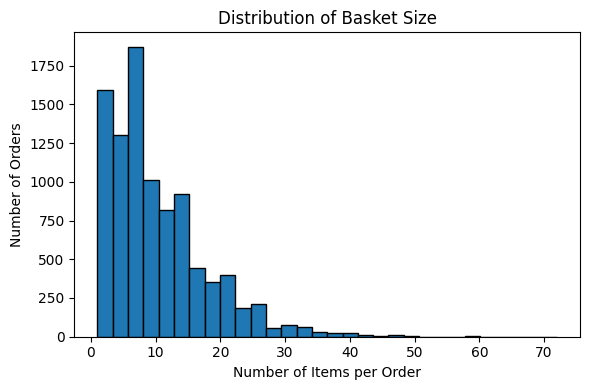

In [11]:
basket_size = sample_order_products.groupby("order_id")["product_id"].count()

basket_size.head()

plt.figure(figsize=(6,4))
plt.hist(basket_size, bins=30, edgecolor='black')
plt.xlabel("Number of Items per Order")
plt.ylabel("Number of Orders")
plt.title("Distribution of Basket Size")
plt.tight_layout()
plt.show()

The basket size distribution is strongly right skewed, with most orders containing fewer than 15 items and a long tail of larger baskets extending beyond 40 items. This indicates that smaller, routine shopping trips are more common than large stock up purchases.

The presence of a long tail suggests variability in shopping behavior, which is important for recommendation modeling. Smaller baskets may reflect targeted purchasing intent, while larger baskets provide richer co purchase signals that can strengthen association rule or collaborative filtering approaches.

### Product Purchase Frequency Distribution

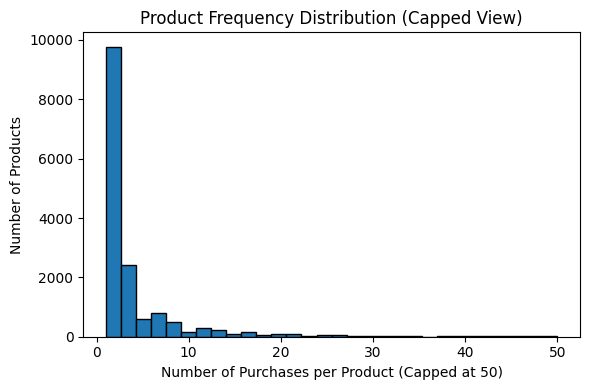

In [12]:
product_freq = instacart_sample["product_name"].value_counts()

product_freq.head()

plt.figure(figsize=(6,4))
plt.hist(product_freq[product_freq <= 50], bins=30, edgecolor='black')
plt.xlabel("Number of Purchases per Product (Capped at 50)")
plt.ylabel("Number of Products")
plt.title("Product Frequency Distribution (Capped View)")
plt.tight_layout()
plt.show()


The distribution of product purchases is strongly right skewed, with most products bought only a few times and a small number purchased frequently. This long tail pattern is typical in retail settings.

For recommendation systems, this highlights the need to balance popular product suggestions with personalized recommendations that capture less frequently purchased items.

### Part 2 Conclusion

Overall, the Instacart Market Basket dataset is **well-structured and usable** for market-basket / recommendation analysis because it is naturally relational (orders ↔ order-product lines ↔ product metadata). For practicality, the full `orders` table (**3,421,083 rows**) and `products` table (**49,688 rows**) were loaded, while the very large prior order-products table was handled via a **sample + chunked filtering** approach.

The EDA shows two key distributional patterns that matter for modeling: (1) **basket sizes are right-skewed** (many small orders, fewer very large orders), and (2) **product purchase frequency is long-tailed** (a small number of products are very common while most are purchased rarely). These patterns suggest that simple popularity baselines will over-recommend frequent items, so downstream recommendation work should account for sparsity/long-tail behavior and consider evaluation strategies that don’t ignore rare-but-relevant products.

Next steps would be to (1) quantify and handle any **class imbalance** in `reordered` (often skewed), (2) validate that sampled results are stable by repeating the sampling with a different random seed or sample size, and (3) proceed to co-purchase / association analysis or collaborative-filtering style features using the order-product structure.

# Part 3: EDA on Amazon Product Reviews

### Initial Data Structure and Contex

In [13]:
# Load Reviews File
reviews = pd.read_json(
    "All_Beauty.jsonl.gz",
    lines=True,
    compression="gzip"
)

#Load Meta Files
meta = pd.read_json(
    "meta_All_Beauty.jsonl.gz",
    lines=True,
    compression="gzip"
)

# Print out df shape
print("All_Beauty Meta Data shape:", meta.shape)
print("All_Beauty Reviews Data shape:", reviews.shape)

# Print head of each df
print("Meta Data:")
display(meta.head())
print("Reviews Data:")
display(reviews.head())

All_Beauty Meta Data shape: (112590, 14)
All_Beauty Reviews Data shape: (701528, 10)
Meta Data:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


Reviews Data:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [14]:
# columns in each df
print("Meta columns:", meta.columns.tolist())
print("Reviews columns:", reviews.columns.tolist())

Meta columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
Reviews columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


The Amazon Reviews dataset is a large scale collection of user product interactions spanning multiple product categories. It contains review level data such as user ratings, written feedback, purchase verification status, and timestamps, along with separate product level metadata including category information, pricing, and descriptive attributes.

Due to the overall scale and density of the full Amazon dataset, the All Beauty category was selected for exploratory analysis. This subset contains 701,528 review records and 112,590 product entries, making it computationally feasible while still preserving meaningful variability in user behavior and product diversity. The All Beauty subset therefore serves as a representative sample for examining rating patterns, review characteristics, and product level structure relevant to recommendation system development.

### Preprocessing

In [15]:
# Check for missing values
print("Missing values in Reviews:")
print(reviews.isnull().sum())
print("\nMissing values in Meta:")
print(meta.isnull().sum())

# Check for duplicates
# Note: some columns (e.g., lists/dicts like `images`) are unhashable, so we cast them to string first.
print("\nNumber of duplicate rows in Reviews:")
reviews_for_dupes = reviews.assign(images=reviews["images"].astype(str))
print(reviews_for_dupes.duplicated().sum())

print("\nNumber of duplicate rows in Meta:")
meta_for_dupes = meta.copy()
for col in ["features", "description", "images", "videos", "categories", "details", "bought_together"]:
    if col in meta_for_dupes.columns:
        meta_for_dupes[col] = meta_for_dupes[col].astype(str)
print(meta_for_dupes.duplicated().sum())

Missing values in Reviews:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

Missing values in Meta:
main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               94886
images                  0
videos                  0
store               11331
categories              0
details                 0
parent_asin             0
bought_together    112590
dtype: int64

Number of duplicate rows in Reviews:
7275

Number of duplicate rows in Meta:
0


The reviews dataset was evaluated for missing values and duplicate records. No missing values were identified in key variables such as rating, review text, or product identifiers. However, 7,275 duplicate rows were detected in the reviews dataset. These duplicate entries likely represent repeated review records and could inflate product level engagement metrics if not addressed. For modeling purposes, removing duplicate rows would be the most appropriate approach to ensure accurate user product interaction counts.

The metadata dataset was checked for duplication and contains no duplicate product records. Core descriptive fields such as title, average rating, and category are complete. However, certain attributes contain substantial missing values. The price field is largely missing, the store field is partially missing, and the bought together field is entirely missing.

Given the extent of missingness in these metadata fields, imputing values using a mean or arbitrary replacement would introduce artificial signals. A more appropriate strategy would be to exclude heavily missing variables from early modeling or treat missingness as its own category if analytically meaningful. For exploratory analysis, the focus remains on well populated attributes such as ratings, categories, and review text.

### Rating Distribution

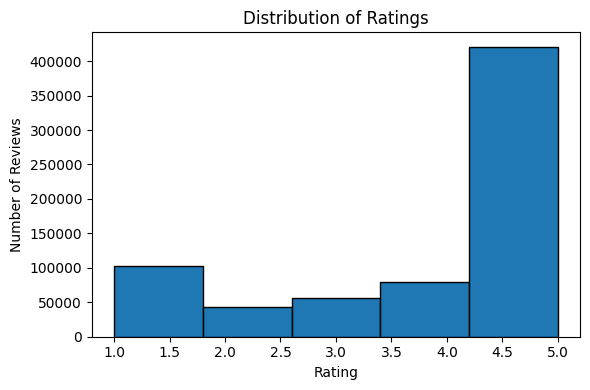

In [16]:
plt.figure(figsize=(6,4))
plt.hist(reviews["rating"], bins=5, edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Ratings")
plt.tight_layout()
plt.show()

The rating distribution is skewed toward higher values, with most reviews concentrated in the 4 and 5 star range. This imbalance is common in online retail platforms and may introduce class imbalance challenges for supervised sentiment or rating prediction models.

### Review Length Distribution

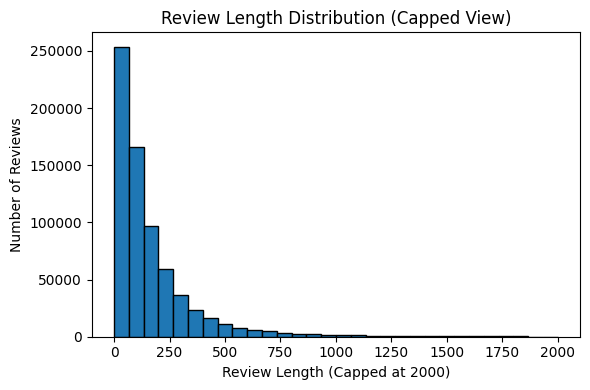

In [17]:
reviews["review_length"] = reviews["text"].astype(str).apply(len)

plt.figure(figsize=(6,4))
plt.hist(reviews["review_length"][reviews["review_length"] <= 2000], bins=30, edgecolor='black')
plt.xlabel("Review Length (Capped at 2000)")
plt.ylabel("Number of Reviews")
plt.title("Review Length Distribution (Capped View)")
plt.tight_layout()
plt.show()

The distribution is strongly right skewed, with most reviews under 2000 characters and a small number of extreme outliers extending far beyond that range. This indicates that most customers provide brief feedback, while a limited subset contributes detailed narratives.

The strong skew and presence of extreme outliers suggest that text preprocessing steps such as length normalization or truncation may be necessary for natural language modeling. The variability in review length also highlights differences in engagement levels among customers.

### Part 3 Conclusion

Overall, the Amazon All Beauty subset is **useful for recommendation and NLP-style analysis** because it captures both (1) user→product interactions from the reviews table and (2) product attributes from the metadata table. In this analysis, the subset includes **701,528 review records** and **112,590 product metadata records**, which is large enough to show real-world sparsity patterns while still being feasible to explore in a notebook.

The EDA also highlights two important distributional patterns: (1) **ratings are skewed high** (many 4–5 star reviews), which implies **class imbalance** if you build a supervised model (sentiment/rating prediction), and (2) **review lengths are strongly right-skewed** with extreme outliers, meaning text preprocessing choices (e.g., truncation, cleaning, and length-aware modeling) will matter. Together, these patterns suggest that simple baselines may overfit to the majority high-rating class and that evaluation should consider imbalance-aware metrics.

Next steps would be to (1) de-duplicate the reviews dataset, (2) engineer text features (tokenization/cleaning, length caps), (3) join reviews to metadata via `parent_asin` when needed for content-based recommendation, and (4) quantify sparsity (reviews per product, reviews per user) to guide whether a collaborative-filtering approach, content-based approach, or hybrid is most appropriate.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

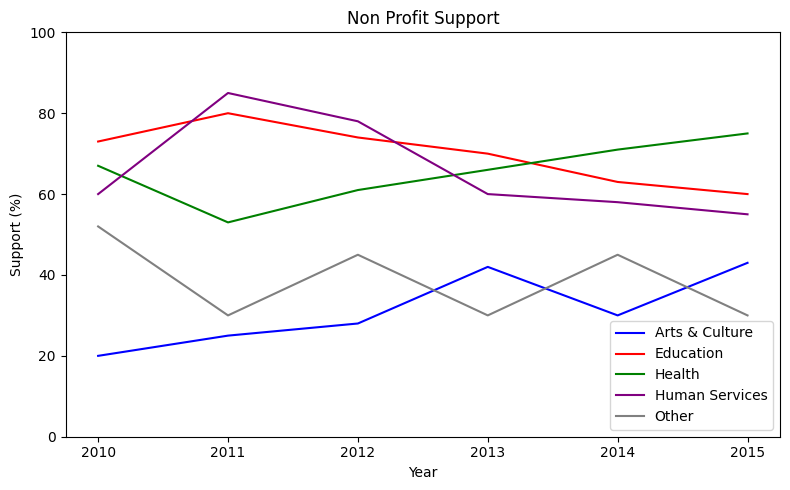

In [23]:
years = [2010, 2011, 2012, 2013, 2014, 2015]

# Rough values to match shape of original
arts_culture = [20, 25, 28, 42, 30, 43]
education = [73, 80, 74, 70, 63, 60]
health = [67, 53, 61, 66, 71, 75]
human_services = [60, 85, 78, 60, 58, 55]
other = [52, 30, 45, 30, 45, 30]

plt.figure(figsize=(8,5))

plt.plot(years, arts_culture, label="Arts & Culture", color="blue")
plt.plot(years, education, label="Education", color="red")
plt.plot(years, health, label="Health", color="green")
plt.plot(years, human_services, label="Human Services", color="purple")
plt.plot(years, other, label="Other", color="grey")

plt.title("Non Profit Support")
plt.xlabel("Year")
plt.ylabel("Support (%)")
plt.ylim(0, 100)

plt.legend()
plt.tight_layout()
plt.show()


This graph can be seen on `page 19` in the Introduction of SWD. I have recreated it from scratch using the exact same colors, labels. I tried my best to roughly match the data points as well! I chose this graph because it seemed the easiest to recreate from scratch without having access to any of the actual data.